In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys
import os
sys.path.append(os.path.abspath("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main"))

from Scripts_Imane import features
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import SpectralBiclustering
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.metrics import consensus_score
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold, cross_val_score


In [5]:
from Scripts_Imane import features
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayesian_splitgenes_latest_phase2(5.18).csv')
def split_genes_with_counts(data):
    rows = []
    for _, row in data.iterrows():
        full_genes = str(row['mutated_genes']).strip()
        genes = [g.strip() for g in full_genes.replace('&', ',').split(',') if g.strip()]
        mutation_count = len(genes)
        for gene in genes:
            new_row = row.copy()
            new_row['mutated_genes'] = gene
            new_row['full_mutated_genes'] = full_genes
            new_row['mutation_count'] = mutation_count
            # Append mutation count to mutant_ID
            new_row['mutant_ID'] = f"{row['mutant_ID']}({mutation_count})"
            rows.append(new_row)
    data_expanded = pd.DataFrame(rows).reset_index(drop=True)
    if data_expanded.empty:
        print("Warning: no rows generated in split_genes_with_counts")
    return data_expanded

data = split_genes_with_counts(data)
data = features.add_GO(data, '/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/GOmart_export.csv')
data.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayesian_splitgenes_latest_phase2(5.18)_GO.csv', index=False)

In [ ]:
# ======== Creating csv from txt file ========

txt_file = "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/mart_export.txt"
csv_file = "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/GOmart_export.csv"
df = pd.read_csv(txt_file, sep=None, engine="python", dtype=str)
if df.shape[1] == 1:
    df = pd.read_csv(txt_file, sep=",", header=None, dtype=str, engine="python")
    df.columns = [
        "Gene Name","Transcript Name","PFAM ID","Pathway ID","Pathway Description",
        "GO ID","GO Description","Panther ID","Panther Description","Description"
    ]
df.to_csv(csv_file, index=False)
print(df.shape)

(95482, 10)


# gènes = 589
# GO terms distincts = 232
# GO terms après filtre (≥3 gènes) = 226
# gènes uniques = 589
Distribution (#GO terms → #genes):
n_GO
0    267
1     95
2     82
3     50
4     65
5     21
6      6
7      1
9      2
Name: count, dtype: int64
   n_GO_terms  n_genes
0           0      267
1           1       95
2           2       82
3           3       50
4           4       65
5           5       21
6           6        6
7           7        1
8           9        2


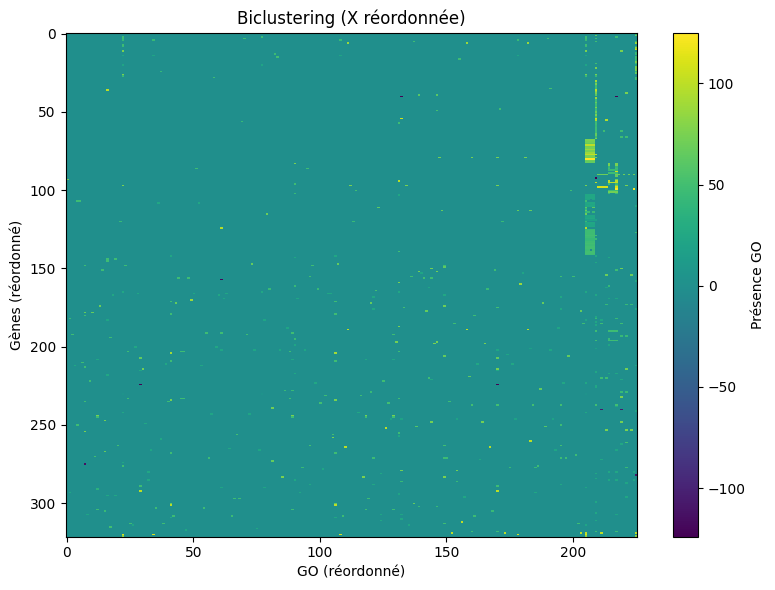


--- Aperçu gènes par cluster ---
gene_cluster
0     30
1     38
2     15
3     20
4     22
5     17
6    177
7      3
Name: count, dtype: int64

--- Aperçu GO par cluster ---
go_cluster
0    205
1      4
2      1
3      4
4      3
5      1
6      7
7      1
Name: count, dtype: int64
Bicluster 8: 0 genes, 0 GO terms
Genes: []
GO terms: []

Bicluster 0: 30 genes, 205 GO terms
Genes (first 100): ['Cre01.g033700', 'Cre01.g038151', 'Cre02.g077951', 'Cre03.g171650', 'Cre04.g212550', 'Cre04.g213652', 'Cre05.g236700', 'Cre06.g285900', 'Cre07.g315850', 'Cre07.g323450', 'Cre07.g325762', 'Cre07.g337582', 'Cre07.g339104', 'Cre07.g340400', 'Cre07.g341900', 'Cre09.g403800', 'Cre09.g411600', 'Cre10.g430900', 'Cre10.g437300', 'Cre11.g467741', 'Cre11.g478128', 'Cre12.g488400', 'Cre13.g590600', 'Cre13.g602700', 'Cre14.g627576', 'Cre15.g635800', 'Cre15.g640101', 'Cre16.g668250', 'Cre16.g677001', 'Cre24.g755747']
GO terms (first 10): ['GO:0000139', 'GO:0000160', 'GO:0000398', 'GO:0000413', 'GO:0000796', 

In [ ]:
### Biclustering
def to_go_list(x):
    if isinstance(x, list):
        return [g for g in x if pd.notna(g)]
    if isinstance(x, str):
        return [g for g in x.split() if g]  
    return []
data = data.copy()
data['GO'] = data['GO'].apply(to_go_list)

data['n_GO_per_gene'] = data['GO'].apply(len)
n_go_per_gene = data[['mutated_genes', 'n_GO_per_gene']]

all_go = set()
_ = data['GO'].apply(all_go.update)
n_go_total = len(all_go)

print(f"# gènes = {data['mutated_genes'].nunique()}")
print(f"# GO terms distincts = {n_go_total}")

exploded = data[['mutated_genes', 'GO']].explode('GO').dropna()
X = pd.crosstab(exploded['mutated_genes'], exploded['GO']).astype(np.int8)

MIN_GENES_PER_GO = 3
keep_go = (X.sum(axis=0) >= MIN_GENES_PER_GO)
X = X.loc[:, keep_go]

print(f"# GO terms après filtre (≥{MIN_GENES_PER_GO} gènes) = {X.shape[1]}")

gene_to_go = data[['mutated_genes', 'GO']].drop_duplicates('mutated_genes')
def to_go_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        return x.split()
    return []
gene_to_go['GO'] = gene_to_go['GO'].apply(to_go_list)
gene_to_go['n_GO'] = gene_to_go['GO'].apply(len)
go_dist = gene_to_go['n_GO'].value_counts().sort_index()
print(f"# gènes uniques = {gene_to_go.shape[0]}")
print("Distribution (#GO terms → #genes):")
print(go_dist)
go_dist_df = go_dist.reset_index()
go_dist_df.columns = ['n_GO_terms', 'n_genes']
print(go_dist_df.head(20))

N_GENE_CLUSTERS = 8
N_GO_CLUSTERS = 8

model = SpectralBiclustering(
    n_clusters=(N_GENE_CLUSTERS, N_GO_CLUSTERS),
    random_state=0
)
model.fit(X)

gene_labels = pd.Series(model.row_labels_, index=X.index, name='gene_cluster')
go_labels   = pd.Series(model.column_labels_, index=X.columns, name='go_cluster')

row_order = np.argsort(model.row_labels_)
col_order = np.argsort(model.column_labels_)
X_ordered = X.iloc[row_order, col_order]

gene_cluster_table = gene_labels.to_frame().reset_index(names='mutated_genes')
go_cluster_table   = go_labels.to_frame().reset_index(names='GO')

plt.figure(figsize=(8, 6))
plt.imshow(X_ordered, aspect='auto', interpolation='nearest')
plt.title('Biclustering (X réordonnée)')
plt.xlabel('GO (réordonné)')
plt.ylabel('Gènes (réordonné)')
plt.colorbar(label='Présence GO')
plt.tight_layout()
plt.show()

print("\n--- Aperçu gènes par cluster ---")
print(gene_cluster_table['gene_cluster'].value_counts().sort_index())
print("\n--- Aperçu GO par cluster ---")
print(go_cluster_table['go_cluster'].value_counts().sort_index())

def get_block_members(g_cluster, go_cluster):
    rows = gene_labels[gene_labels == g_cluster].index
    cols = go_labels[go_labels == go_cluster].index
    return rows.tolist(), cols.tolist()

# rows, cols = get_block_members(0, 0)
# print("Gènes du bloc (0,0):", rows[:10])
# print("GO du bloc (0,0):", cols[:10])
k = N_GENE_CLUSTERS
rows = gene_labels[gene_labels == k].index  
cols = go_labels[go_labels == k].index  
print(f"Bicluster {k}: {len(rows)} genes, {len(cols)} GO terms")
print("Genes:", rows[:10].tolist())   # print first 10
print("GO terms:", cols[:10].tolist())
for k in range(model.n_clusters[0]):
    rows = gene_labels[gene_labels == k].index
    cols = go_labels[go_labels == k].index
    print(f"\nBicluster {k}: {len(rows)} genes, {len(cols)} GO terms")
    print("Genes (first 100):", rows[:100].tolist())
    print("GO terms (first 10):", cols[:10].tolist())


In [ ]:

# fit two models with different cluster numbers
model1 = SpectralBiclustering(n_clusters=(5,5), random_state=0).fit(X)
model2 = SpectralBiclustering(n_clusters=(10,10), random_state=0).fit(X)

score = consensus_score(model1.biclusters_, model2.biclusters_)
print("Consensus score:", score)


Consensus score: 0.12560228014084507


In [ ]:
# Stats of how many features
df_gene = df.groupby('mutated_genes', as_index=False).agg({
    'GO': lambda x: sum([xi if isinstance(xi, list) else [] for xi in x], []),
    'Pathway Description': lambda x: sum([xi if isinstance(xi, list) else [] for xi in x], []),
    'Panther ID': lambda x: sum([xi if isinstance(xi, list) else [] for xi in x], [])
})

def has_nonempty(x):
    return isinstance(x, list) and len([v for v in x if str(v).strip() != ""]) > 0

df_gene['has_GO']      = df_gene['GO'].apply(has_nonempty)
df_gene['has_pathway'] = df_gene['Pathway Description'].apply(has_nonempty)
df_gene['has_panther'] = df_gene['Panther ID'].apply(has_nonempty)

total_genes  = df_gene.shape[0]
with_GO      = df_gene['has_GO'].sum()
with_pathway = df_gene['has_pathway'].sum()
with_panther = df_gene['has_panther'].sum()
with_any     = ((df_gene['has_GO']) | (df_gene['has_pathway']) | (df_gene['has_panther'])).sum()

print(f"Total unique genes: {total_genes}")
print(f"Genes with GO: {with_GO}")
print(f"Genes with Pathway Description: {with_pathway}")
print(f"Genes with Panther ID: {with_panther}")
print(f"Genes with at least one (GO or Pathway or Panther): {with_any}")


In [ ]:
#### missing geneesss
genes_all = set(data['mutated_genes'].unique())

exploded0 = data[['mutated_genes','GO']].explode('GO')
s = exploded0.dropna(subset=['mutated_genes','GO']).reset_index(drop=True)

X_full = pd.crosstab(s['mutated_genes'], s['GO']).astype('int8')

MIN_GENES_PER_GO = 3
keep_go = (X_full.sum(axis=0) >= MIN_GENES_PER_GO)
X_filt = X_full.loc[:, keep_go]

lost_by_filter = X_filt.index[X_filt.sum(axis=1) == 0].tolist()

print(X_full.shape, X_filt.shape, len(lost_by_filter))

MIN_GENES_PER_GO = 3
keep_go = (X_full.sum(axis=0) >= MIN_GENES_PER_GO)
X_filt = X_full.loc[:, keep_go]

lost_by_filter = sorted(X_filt.sum(axis=1)[X_filt.sum(axis=1) == 0].index)

genes_in_X = set(X_filt.index)

print(f"Total gènes (data): {len(genes_all)}")
print(f"Dans X (biclustering): {len(genes_in_X)}")
print(f"Sans aucun GO: {len(genes_no_go)}")
print(f"Perdus par le filtre GO (trop rares): {lost_by_filter}")

(322, 232) (322, 226) 1
Total gènes (data): 589
Dans X (biclustering): 322
Sans aucun GO: 267
Perdus par le filtre GO (trop rares): ['Cre10.g440850']


Après nettoyage: 314 gènes × 226 GO


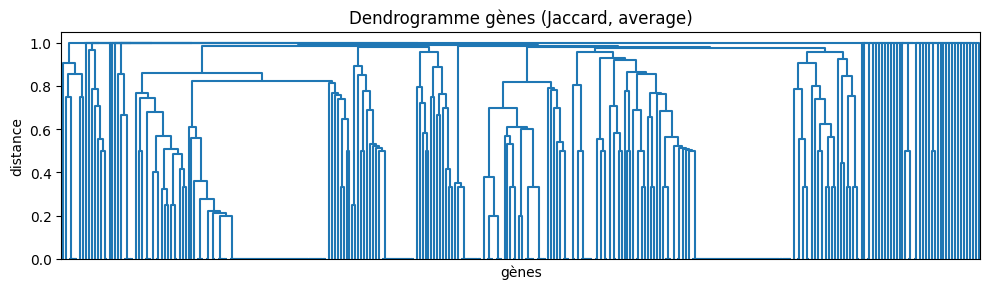

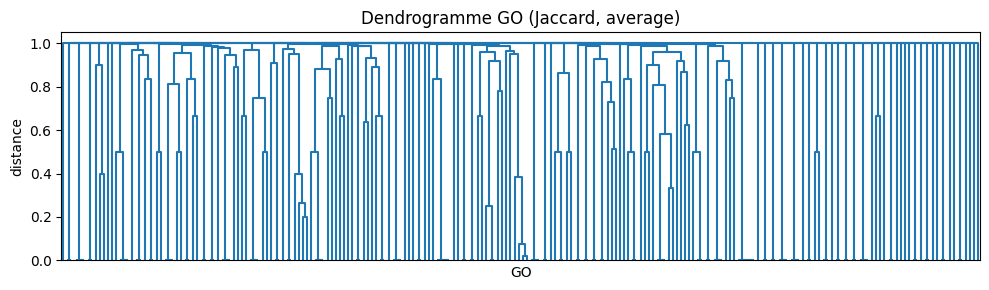


--- Gènes par cluster ---
gene_cluster
0      7
1      1
2      6
3      1
4      6
5     74
6     22
7      5
8      8
9     10
10    30
11     8
12     5
13     5
14    58
15     6
16     9
17     7
18     1
19     1
20     1
21     1
22     1
23     2
24     3
25     2
26     2
27     1
28     1
29     1
30     1
31     1
32     1
33     1
34     1
35     1
36     1
37     1
38     1
39     1
40     1
41     1
42     1
43     1
44     1
45     1
46     1
47     1
48     1
49     1
50     1
51     1
52     1
53     1
54     1
55     1
56     1
57     1
58     1
Name: count, dtype: int64

--- GO par cluster ---
go_cluster
0    226
Name: count, dtype: int64


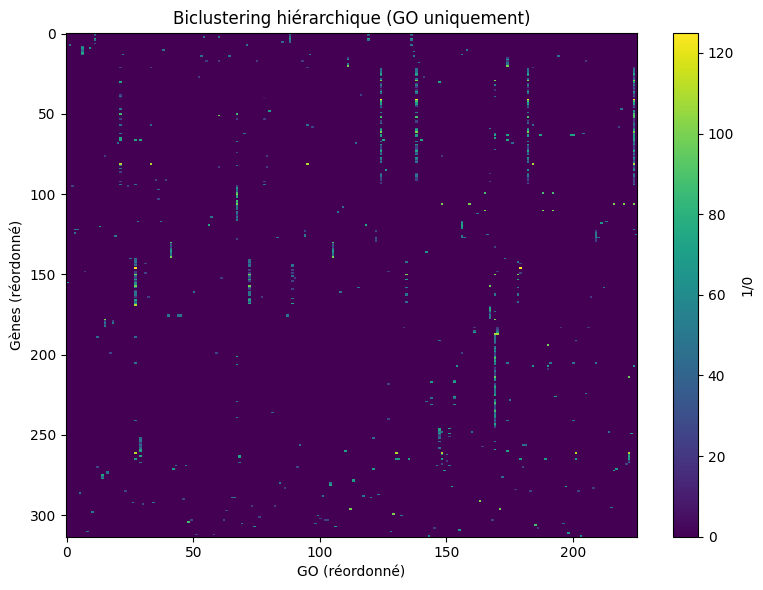

Bicluster (0,0): 7 gènes × 226 GO, densité=0.662
Bicluster (1,0): 1 gènes × 226 GO, densité=0.637
Bicluster (2,0): 6 gènes × 226 GO, densité=0.507
Bicluster (3,0): 1 gènes × 226 GO, densité=0.832
Bicluster (4,0): 6 gènes × 226 GO, densité=0.521
Bicluster (5,0): 74 gènes × 226 GO, densité=0.874
Bicluster (6,0): 22 gènes × 226 GO, densité=0.509
Bicluster (7,0): 5 gènes × 226 GO, densité=0.665
Bicluster (8,0): 8 gènes × 226 GO, densité=0.614
Bicluster (9,0): 10 gènes × 226 GO, densité=0.545
Bicluster (10,0): 30 gènes × 226 GO, densité=0.693
Bicluster (11,0): 8 gènes × 226 GO, densité=0.453
Bicluster (12,0): 5 gènes × 226 GO, densité=0.371
Bicluster (13,0): 5 gènes × 226 GO, densité=0.502
Bicluster (14,0): 58 gènes × 226 GO, densité=0.365
Bicluster (15,0): 6 gènes × 226 GO, densité=0.518
Bicluster (16,0): 9 gènes × 226 GO, densité=0.504
Bicluster (17,0): 7 gènes × 226 GO, densité=1.178
Bicluster (18,0): 1 gènes × 226 GO, densité=0.221
Bicluster (19,0): 1 gènes × 226 GO, densité=0.850
Biclu

In [ ]:
#  Jaccard dendogram
Xc = X.loc[X.sum(axis=1) > 0, X.sum(axis=0) > 0]
print(f"Après nettoyage: {Xc.shape[0]} gènes × {Xc.shape[1]} GO")

Xb = (Xc.values > 0)
row_dist = pdist(Xb, metric='jaccard')
col_dist = pdist(Xb.T, metric='jaccard')

Z_rows = linkage(row_dist, method='average')
Z_cols = linkage(col_dist, method='average')

plt.figure(figsize=(10, 3))
dendrogram(Z_rows, no_labels=True, color_threshold=0.0)
plt.title("Dendrogramme gènes (Jaccard, average)")
plt.xlabel("gènes"); plt.ylabel("distance")
plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 3))
dendrogram(Z_cols, no_labels=True, color_threshold=0.0)
plt.title("Dendrogramme GO (Jaccard, average)")
plt.xlabel("GO"); plt.ylabel("distance")
plt.tight_layout(); plt.show()

ROW_THRESH = 0.9  
COL_THRESH = 1

row_labels = fcluster(Z_rows, ROW_THRESH, criterion='distance') - 1
col_labels = fcluster(Z_cols, COL_THRESH, criterion='distance') - 1
gene_labels = pd.Series(row_labels, index=Xc.index, name='gene_cluster')
go_labels   = pd.Series(col_labels, index=Xc.columns, name='go_cluster')

print("\n--- Gènes par cluster ---")
print(gene_labels.value_counts().sort_index())
print("\n--- GO par cluster ---")
print(go_labels.value_counts().sort_index())

rord = np.argsort(row_labels); cord = np.argsort(col_labels)
X_ordered = Xc.iloc[rord, cord]

plt.figure(figsize=(8,6))
plt.imshow(X_ordered, aspect='auto', interpolation='nearest')
plt.title('Biclustering hiérarchique (GO uniquement)')
plt.xlabel('GO (réordonné)'); plt.ylabel('Gènes (réordonné)')
plt.colorbar(label='1/0'); plt.tight_layout(); plt.show()

def get_block(g_cluster, go_cluster):
    rows = gene_labels[gene_labels == g_cluster].index
    cols = go_labels[go_labels == go_cluster].index
    return rows.tolist(), cols.tolist()

def block_density(rows, cols):
    if len(rows)==0 or len(cols)==0: return np.nan
    sub = Xc.loc[rows, cols].values
    return sub.sum() / (sub.shape[0]*sub.shape[1])

for gk in sorted(gene_labels.unique()):
    for fk in sorted(go_labels.unique()):
        r,c = get_block(gk,fk)
        d = block_density(r,c)
        print(f"Bicluster ({gk},{fk}): {len(r)} gènes × {len(c)} GO, densité={d:.3f}")


In [ ]:
### predictive power of GO terms
def make_X_from_GO(df, min_genes_per_go=3):
    g = df[['mutated_genes','GO']].dropna(subset=['mutated_genes']).copy()
    def to_list(x):
        if isinstance(x, list): return [v for v in x if pd.notna(v)]
        if pd.isna(x): return []
        return str(x).split()
    g['GO'] = g['GO'].apply(to_list)

    expl = g.explode('GO').dropna(subset=['GO'])
    X = pd.crosstab(expl['mutated_genes'], expl['GO']).astype(np.uint8)

    if min_genes_per_go is not None and min_genes_per_go > 1:
        keep = X.sum(axis=0) >= min_genes_per_go
        X = X.loc[:, keep]

    return X

X = make_X_from_GO(data, min_genes_per_go=3)
print(X.shape)

PC_mat = PC_df.set_index('mutated_genes').loc[X.index].to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

results = {}
for pc in range(5):
    y = PC[:, pc]
    model = RidgeCV(alphas=np.logspace(-3, 3, 20))
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring="r2")
    results[f"PC{pc+1}"] = scores.mean()

print("R² moyens par PC :")
print(results)


In [ ]:
# Count how many regimes each gene has
counts = (
    df.dropna(subset=["y2_slope"])
      .groupby("mutated_genes")["light_regime"]
      .nunique()
      .reset_index(name="n_nonnull_regimes")
)

# Distribution: how many mutants have 8,7,6... regimes
distribution = counts["n_nonnull_regimes"].value_counts().sort_index()

print("Counts per mutant_ID (first 10):")
print(counts.head(10))

print("\nDistribution of regime counts:")
print(distribution)


Counts per mutant_ID (first 10):
   mutated_genes  n_nonnull_regimes
0  Cre01.g000100                  8
1  Cre01.g000650                  8
2  Cre01.g001200                  8
3  Cre01.g001800                  8
4  Cre01.g003650                  8
5  Cre01.g003700                  8
6  Cre01.g004124                  8
7  Cre01.g004950                  8
8  Cre01.g007700                  8
9  Cre01.g007737                  8

Distribution of regime counts:
n_nonnull_regimes
1      2
3      1
7      1
8    585
Name: count, dtype: int64


Explained variance ratio (par PC): [0.511, 0.177, 0.089, 0.07, 0.045, 0.044, 0.038, 0.026]


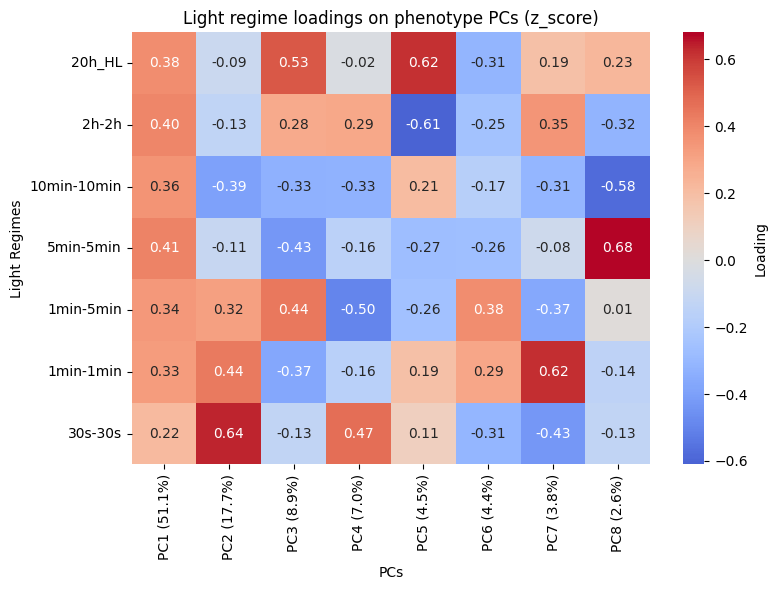

    PC  variance_pct  cum_pct
0  PC1         51.08    51.08
1  PC2         17.75    68.83
2  PC3          8.94    77.77
3  PC4          6.96    84.73
4  PC5          4.51    89.24
5  PC6          4.35    93.59
6  PC7          3.78    97.36
7  PC8          2.64   100.00

R² CV par PC:
PC1: -0.033
PC2: -0.069
PC3: -0.045
PC4: -0.044
PC5: -0.025
PC6: -0.067
PC7: -0.048
PC8: -0.047

R² CV moyen (toutes PCs): -0.047


In [ ]:
## pcs projection using go
df=data
df = data
df = df[~(df['mutant_ID']== 'WT')]
df = df[df['mutated_genes'].notna() & df['mutant_ID'].notna()]
df = df[~(df['light_regime'].isin(['20h_ML']))]

def to_go_list(x):
    if isinstance(x, list): return [g for g in x if pd.notna(g) and str(g).strip()!=""]
    if isinstance(x, str):  return [g for g in x.split() if g]
    return []

def make_Y(df, gene_col='mutant_ID', light_col='light_regime', slope_col='y2_slope'):
    g = (df[[gene_col, light_col, slope_col]]
         .dropna(subset=[gene_col, light_col, slope_col]))
    Y = (g.groupby([gene_col, light_col])[slope_col]
           .mean().unstack(light_col))
    Y = Y.dropna(axis=0, how='any')  # gènes avec mesures complètes
    return Y

def make_X_from_GO(df, gene_col='mutated_genes', go_col='GO', min_genes_per_go=3):
    g = df[[gene_col, go_col]].dropna(subset=[gene_col]).copy()
    g[go_col] = g[go_col].apply(to_go_list)
    expl = g.explode(go_col).dropna(subset=[go_col])
    X = pd.crosstab(expl[gene_col], expl[go_col]).astype(np.uint8)
    if min_genes_per_go and min_genes_per_go > 1:
        keep = X.sum(axis=0) >= min_genes_per_go
        X = X.loc[:, keep]
    return X

# ---------------------------------------
# 1) Construire Y (moyenne des slopes)
#    ATTENTION: adapte les noms de colonnes si besoin
# ---------------------------------------
Y = make_Y(data, gene_col='mutated_genes', light_col='light_regime', slope_col='z_score')

# ---------------------------------------
# 2) Construire X (gène × GO binaire)
# ---------------------------------------
X = make_X_from_GO(data, gene_col='mutated_genes', go_col='Panther ID', min_genes_per_go=3)

# ---------------------------------------
# 3) Aligner X et Y (gènes communs) + clean
# ---------------------------------------
genes = X.index.intersection(Y.index)
X = X.loc[genes]
Y = Y.loc[genes]
X = X.loc[:, X.sum(axis=0) > 0]  # retire features vides

# ---------------------------------------
# 4) PCA sur Y (standardisation conseillée)
# ---------------------------------------
Y = Y.replace([np.inf, -np.inf], 0)

scaler_Y = StandardScaler()
Y_scaled = scaler_Y.fit_transform(Y.values)

n_pcs = min(8, Y.shape[1])  # ex: 5 PC ou max possible
pca = PCA(n_components=n_pcs, random_state=0)
PC_scores = pca.fit_transform(Y_scaled)
PC_df = pd.DataFrame(PC_scores, index=Y.index,
                     columns=[f'PC{i+1}' for i in range(n_pcs)])

print("Explained variance ratio (par PC):",
      [round(v, 3) for v in pca.explained_variance_ratio_])


pca.fit(Y_scaled)
explained_var = pca.explained_variance_ratio_ * 100
loadings = pd.DataFrame(
    pca.components_.T,   # transpose pour avoir regimes en lignes
    index=Y.columns,     # light regimes
    columns=[f"PC{i+1} ({explained_var[i]:.1f}%)" for i in range(pca.n_components_)])
order = ["20h_HL", "2h-2h", "10min-10min", 
         "5min-5min", "1min-5min", "1min-1min", "30s-30s"]
loadings = loadings.loc[order]
plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            cbar_kws={"label": "Loading"})
plt.title("Light regime loadings on phenotype PCs (z_score)")
plt.ylabel("Light Regimes")
plt.xlabel("PCs")
plt.tight_layout()
plt.show()

# 5) Variance expliquée (même présentation)
evr = pca.explained_variance_ratio_
pc_names = [f"PC{i+1}" for i in range(pca.n_components_)]
print(pd.DataFrame({
    "PC": pc_names,
    "variance_pct": 100*evr,
    "cum_pct": 100*np.cumsum(evr)
}).round(2))
# ---------------------------------------
# 5) Régression: GO -> PCs (pouvoir prédictif R² CV)
#    On calcule un R² CV PAR PC, puis la moyenne.
# ---------------------------------------
cv_splits = max(2, min(5, len(genes)))  # sécurité si peu d’échantillons
kf = KFold(n_splits=cv_splits, shuffle=True, random_state=0)

alphas = np.logspace(-3, 3, 20)
r2_per_pc = {}
for j, pc_name in enumerate(PC_df.columns):
    y = PC_df.iloc[:, j].values
    model = RidgeCV(alphas=alphas, cv=kf)
    scores = cross_val_score(model, X.values, y, cv=kf, scoring='r2')
    r2_per_pc[pc_name] = float(scores.mean())

r2_mean = float(np.mean(list(r2_per_pc.values())))

print("\nR² CV par PC:")
for k, v in r2_per_pc.items():
    print(f"{k}: {v:.3f}")
print(f"\nR² CV moyen (toutes PCs): {r2_mean:.3f}")
